# Baseline: ConvNeXt-Tiny for Rice Leaf Disease Classification
**Config:** ImageNet-1K pretrained | GELU activation | Stochastic Depth | LayerNorm
**Model:** ConvNeXt-Tiny

Dataset: [Rice Leaf Disease Identification Dataset](https://www.kaggle.com/datasets/wangxiaoqii/rice-leaf-disease-identification-dataset)

## 0. Colab Setup (jalankan sekali per session)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_DIR = '/content/drive/MyDrive/rice-convnext/baseline_tiny'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive folder ready: {DRIVE_DIR}')

Mounted at /content/drive
Drive folder ready: /content/drive/MyDrive/rice-convnext/baseline_tiny


In [ ]:
from google.colab import files
import os, shutil
print('Upload kaggle.json...')
files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API ready!')

Upload kaggle.json...


Saving kaggle.json to kaggle.json
Kaggle API ready!


In [ ]:
DATASET_DIR = '/content/drive/MyDrive/rice-convnext/dataset'
if os.path.exists(DATASET_DIR) and len(os.listdir(DATASET_DIR)) > 0:
    print(f'Dataset sudah ada, skip download.')
else:
    !pip install kaggle -q
    !kaggle datasets download -d wangxiaoqii/rice-leaf-disease-identification-dataset -p /content/tmp
    !unzip -q /content/tmp/*.zip -d {DATASET_DIR}
    !rm -rf /content/tmp
    print('Dataset ready!')

for root, dirs, files_list in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    if level > 1: break
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/ ({len(files_list)} files)')

Dataset sudah ada, skip download.
dataset/ (0 files)
  Bacterial Blight/ (0 files)


In [ ]:
import shutil

LOCAL_DATASET = '/content/dataset'

if not os.path.exists(LOCAL_DATASET):
    print('Copying dataset ke local SSD...')
    shutil.copytree(DATASET_DIR, LOCAL_DATASET)
    print('Done!')
else:
    print('Sudah ada di local.')

DATA_DIR = LOCAL_DATASET

Copying dataset ke local SSD...
Done!


## 1. Setup & Imports

In [ ]:
import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 2. Configuration

In [ ]:
DATA_DIR     = '/content/drive/MyDrive/rice-convnext/dataset'
DRIVE_DIR    = '/content/drive/MyDrive/rice-convnext/baseline_tiny'
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 30
LR_INIT      = 1e-3
LR_FINAL     = 1e-6
WEIGHT_DECAY = 0.05
NUM_WORKERS  = 2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
SAVE_PATH    = f'{DRIVE_DIR}/convnext_convnext_tiny_baseline.pt'
EXP_NAME     = 'ConvNeXt-Tiny | GELU | StochDepth | LayerNorm'
print(f'Experiment: {EXP_NAME}')

Experiment: ConvNeXt-Tiny | GELU | StochDepth | LayerNorm


## 3. Data Loading & Augmentation

In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

full_dataset = datasets.ImageFolder(DATA_DIR)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total images: {len(full_dataset)}')

total   = len(full_dataset)
n_train = int(0.6 * total)
n_val   = int(0.2 * total)
n_test  = total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)

train_set.dataset.transform = train_transforms
val_set.dataset.transform   = val_test_transforms
test_set.dataset.transform  = val_test_transforms

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')

Classes (7): ['Bacterial Blight', 'Bacterial Leaf Streak', 'Brown Spot', 'Healthy', 'Hispa', 'Leaf Blast', 'Sheath Blight']
Total images: 3353
Train: 2011 | Val: 670 | Test: 672


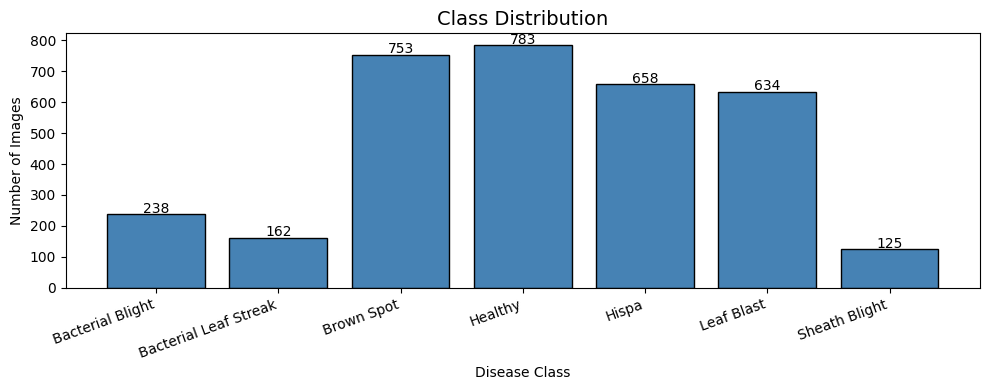

In [ ]:
labels_all = [full_dataset.targets[i] for i in range(len(full_dataset))]
counts = [Counter(labels_all)[i] for i in range(NUM_CLASSES)]
plt.figure(figsize=(10, 4))
bars = plt.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='black')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+5, str(count), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

## 4. Model — ConvNeXt-Tiny

In [ ]:
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_p:,}')
print(f'Trainable params: {trainable_p:,}')

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 179MB/s]


Total params    : 27,825,511
Trainable params: 27,825,511


## 5. Training Setup

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR_INIT, weight_decay=WEIGHT_DECAY)

def get_scheduler(optimizer, num_epochs, lr_init, lr_final):
    warmup = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=1)
    cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs-1, eta_min=lr_final)
    return optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[1])

scheduler = get_scheduler(optimizer, NUM_EPOCHS, LR_INIT, LR_FINAL)

## 6. Training Loop

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, correct / total

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}'
          + (' <- best' if val_acc == best_val_acc else ''))

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')
print(f'Saved: {SAVE_PATH}')

Epoch [01/30] Train Loss: 1.6356 Acc: 0.3933 | Val Loss: 1.3140 Acc: 0.5791 <- best
Epoch [02/30] Train Loss: 0.8527 Acc: 0.6897 | Val Loss: 0.7627 Acc: 0.7134 <- best
Epoch [03/30] Train Loss: 0.5332 Acc: 0.8220 | Val Loss: 0.4598 Acc: 0.8373 <- best
Epoch [04/30] Train Loss: 0.3524 Acc: 0.8787 | Val Loss: 0.4641 Acc: 0.8313
Epoch [05/30] Train Loss: 0.2937 Acc: 0.8981 | Val Loss: 0.4536 Acc: 0.8716 <- best
Epoch [06/30] Train Loss: 0.2198 Acc: 0.9319 | Val Loss: 0.3284 Acc: 0.9045 <- best
Epoch [07/30] Train Loss: 0.2126 Acc: 0.9294 | Val Loss: 0.4551 Acc: 0.8507
Epoch [08/30] Train Loss: 0.2313 Acc: 0.9309 | Val Loss: 0.3541 Acc: 0.8836
Epoch [09/30] Train Loss: 0.1400 Acc: 0.9572 | Val Loss: 0.4942 Acc: 0.8522
Epoch [10/30] Train Loss: 0.0777 Acc: 0.9736 | Val Loss: 0.4937 Acc: 0.8821
Epoch [11/30] Train Loss: 0.1375 Acc: 0.9602 | Val Loss: 0.5276 Acc: 0.8537
Epoch [12/30] Train Loss: 0.1239 Acc: 0.9602 | Val Loss: 0.3245 Acc: 0.9015
Epoch [13/30] Train Loss: 0.0699 Acc: 0.9761 | V

## 7. Training Curves

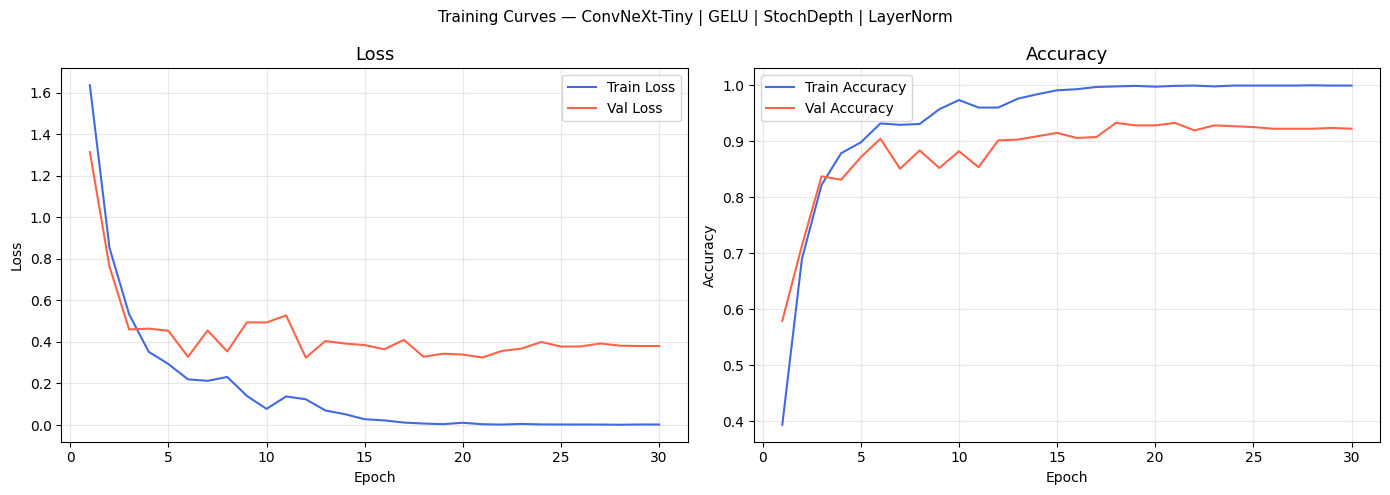

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy', color='royalblue')
axes[1].plot(epochs_range, history['val_acc'],   label='Val Accuracy',   color='tomato')
axes[1].set_title('Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle(f'Training Curves — {EXP_NAME}', fontsize=11)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 8. Evaluation on Test Set

In [ ]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print('=== Classification Report ===')
print(report_df.round(4).to_string())
report_df.to_csv('classification_report.csv')

summary = {
    'Model'    : ['ConvNeXt-Tiny'],
    'Activation': ['GELU'],
    'Dropout'   : ['Stochastic Depth'],
    'Norm'      : ['LayerNorm'],
    'Accuracy'  : [report['accuracy']],
    'Precision' : [report['weighted avg']['precision']],
    'Recall'    : [report['weighted avg']['recall']],
    'F1-Score'  : [report['weighted avg']['f1-score']],
}
summary_df = pd.DataFrame(summary)
print('\n=== Summary ===')
print(summary_df.round(4).to_string(index=False))
summary_df.to_csv('summary.csv', index=False)

=== Classification Report ===
                       precision  recall  f1-score   support
Bacterial Blight          0.9423  0.9074    0.9245   54.0000
Bacterial Leaf Streak     0.8966  0.9286    0.9123   28.0000
Brown Spot                0.9107  0.9217    0.9162  166.0000
Healthy                   0.9515  0.9458    0.9486  166.0000
Hispa                     0.9145  0.9727    0.9427  110.0000
Leaf Blast                0.8783  0.8211    0.8487  123.0000
Sheath Blight             0.8077  0.8400    0.8235   25.0000
accuracy                  0.9137  0.9137    0.9137    0.9137
macro avg                 0.9002  0.9053    0.9024  672.0000
weighted avg              0.9136  0.9137    0.9133  672.0000

=== Summary ===
        Model Activation          Dropout      Norm  Accuracy  Precision  Recall  F1-Score
ConvNeXt-Tiny       GELU Stochastic Depth LayerNorm    0.9137     0.9136  0.9137    0.9133


## 9. Confusion Matrix

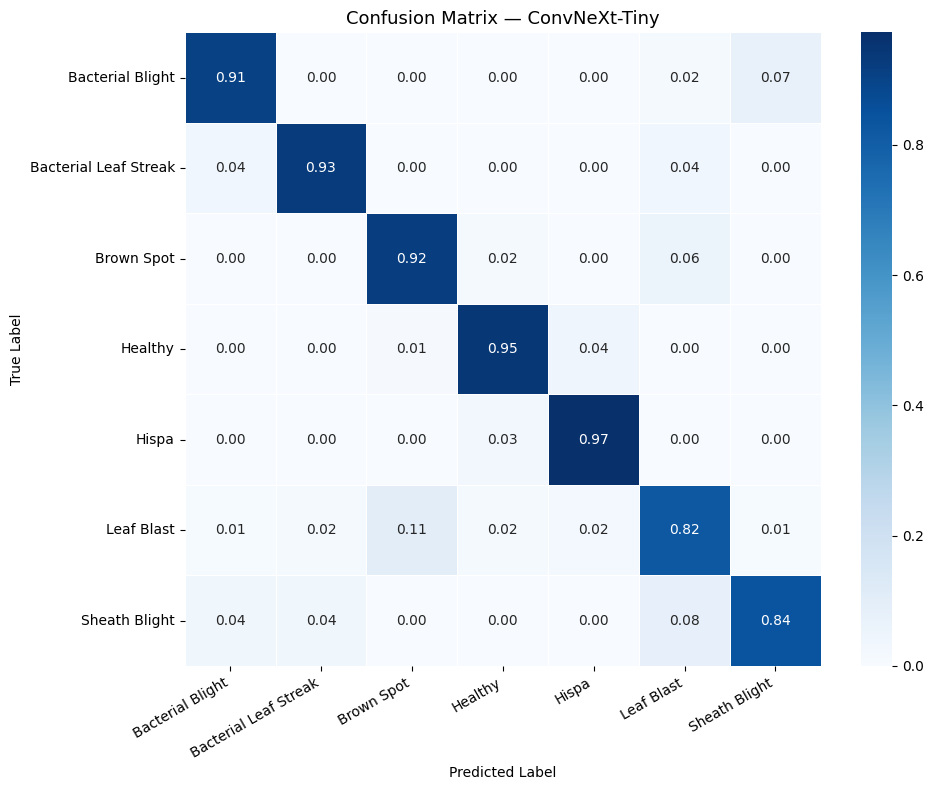

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=0.5)
plt.title(f'Confusion Matrix — ConvNeXt-Tiny', fontsize=13)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 10. Save All to Drive

In [ ]:
local_files = ['training_curves.png', 'confusion_matrix.png',
               'classification_report.csv', 'summary.csv', 'class_distribution.png']
for fname in local_files:
    if os.path.exists(fname):
        shutil.copy(fname, f'{DRIVE_DIR}/{fname}')

all_outputs = [
    (f'{DRIVE_DIR}/convnext_convnext_tiny_baseline.pt', 'Model weights'),
    (f'{DRIVE_DIR}/training_curves.png',                 'Training curves'),
    (f'{DRIVE_DIR}/confusion_matrix.png',                'Confusion matrix'),
    (f'{DRIVE_DIR}/classification_report.csv',           'Per-class metrics'),
    (f'{DRIVE_DIR}/summary.csv',                         'Summary table'),
]
print(f'=== Output Files: {DRIVE_DIR} ===')
for fpath, desc in all_outputs:
    exists = '✅' if os.path.exists(fpath) else '❌'
    print(f'{exists}  {os.path.basename(fpath):<40} {desc}')

=== Output Files: /content/drive/MyDrive/rice-convnext/baseline_tiny ===
✅  convnext_convnext_tiny_baseline.pt       Model weights
✅  training_curves.png                      Training curves
✅  confusion_matrix.png                     Confusion matrix
✅  classification_report.csv                Per-class metrics
✅  summary.csv                              Summary table
